In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/BrentOilPrices.csv")

# Quick look
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(9011, 2)
        Date  Price
0  20-May-87  18.63
1  21-May-87  18.45
2  22-May-87  18.55
3  25-May-87  18.60
4  26-May-87  18.63
Date         str
Price    float64
dtype: object
Date     0
Price    0
dtype: int64


In [2]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)

In [3]:
print(df.index.min(), df.index.max())
print(df.index.year.value_counts().sort_index())

1987-05-20 00:00:00 2022-11-14 00:00:00
Date
1987    160
1988    255
1989    254
1990    256
1991    257
1992    257
1993    252
1994    252
1995    253
1996    254
1997    248
1998    253
1999    249
2000    253
2001    257
2002    255
2003    258
2004    261
2005    257
2006    255
2007    250
2008    253
2009    252
2010    252
2011    248
2012    249
2013    252
2014    254
2015    255
2016    255
2017    256
2018    252
2019    258
2020    256
2021    253
2022    220
Name: count, dtype: int64


In [4]:
print(df.head())
print(df.tail())

            Price
Date             
1987-05-20  18.63
1987-05-21  18.45
1987-05-22  18.55
1987-05-25  18.60
1987-05-26  18.63
            Price
Date             
2022-11-08  96.85
2022-11-09  93.05
2022-11-10  94.25
2022-11-11  96.37
2022-11-14  93.59


In [5]:
import os
os.makedirs("../reports/figures", exist_ok=True)

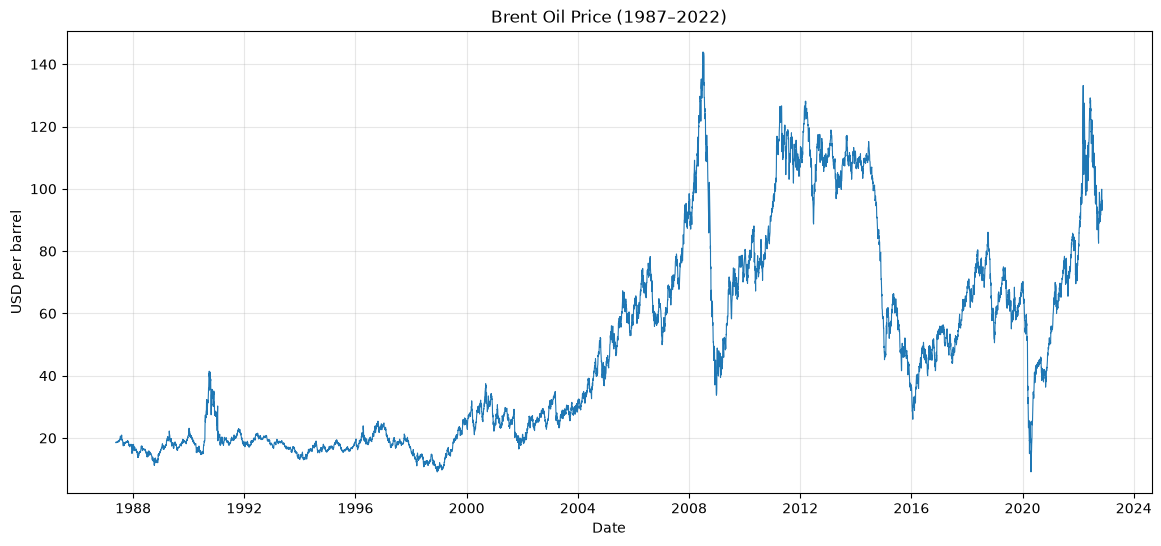

In [6]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Price'], linewidth=0.8)
plt.title('Brent Oil Price (1987–2022)')
plt.xlabel('Date')
plt.ylabel('USD per barrel')
plt.grid(alpha=0.3)
plt.show()

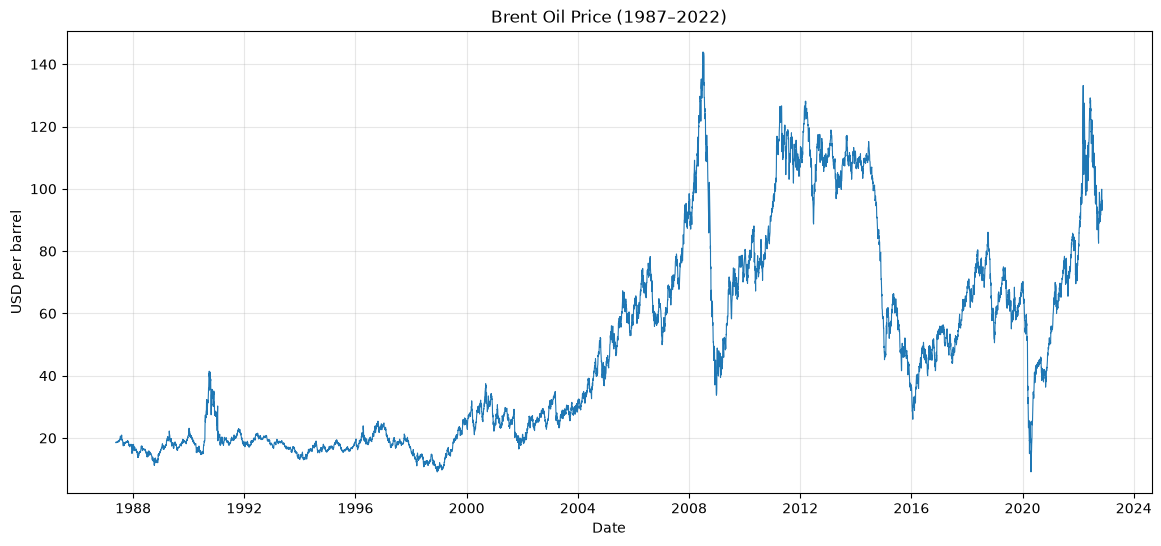

In [7]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Price'], linewidth=0.8)
plt.title('Brent Oil Price (1987–2022)')
plt.xlabel('Date')
plt.ylabel('USD per barrel')
plt.grid(alpha=0.3)
plt.savefig("../reports/figures/brent_price_raw.png", dpi=150, bbox_inches='tight')
plt.show()

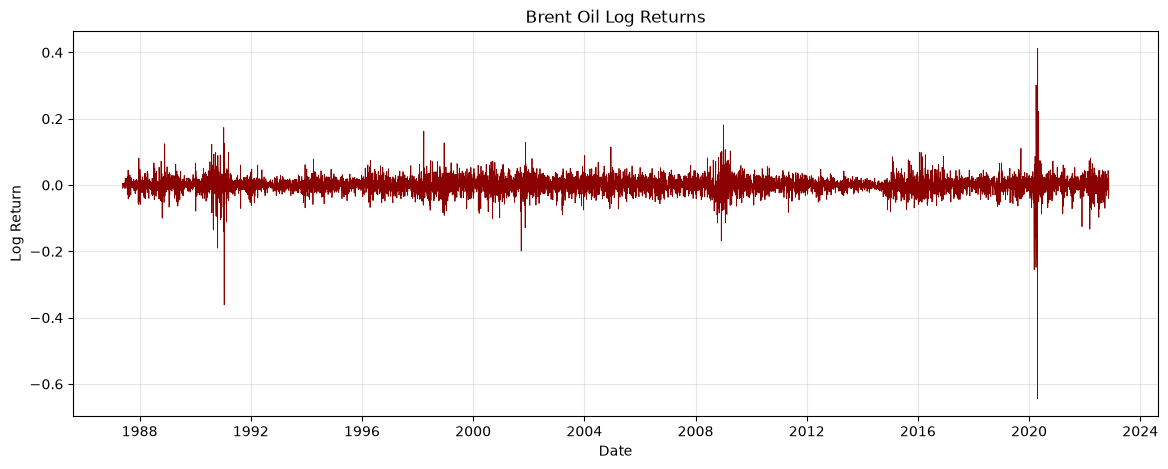

In [8]:
df['LogPrice'] = np.log(df['Price'])
df['LogReturn'] = df['LogPrice'].diff()

plt.figure(figsize=(14,5))
plt.plot(df.index, df['LogReturn'], linewidth=0.6, color='darkred')
plt.title('Brent Oil Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(alpha=0.3)
plt.show()

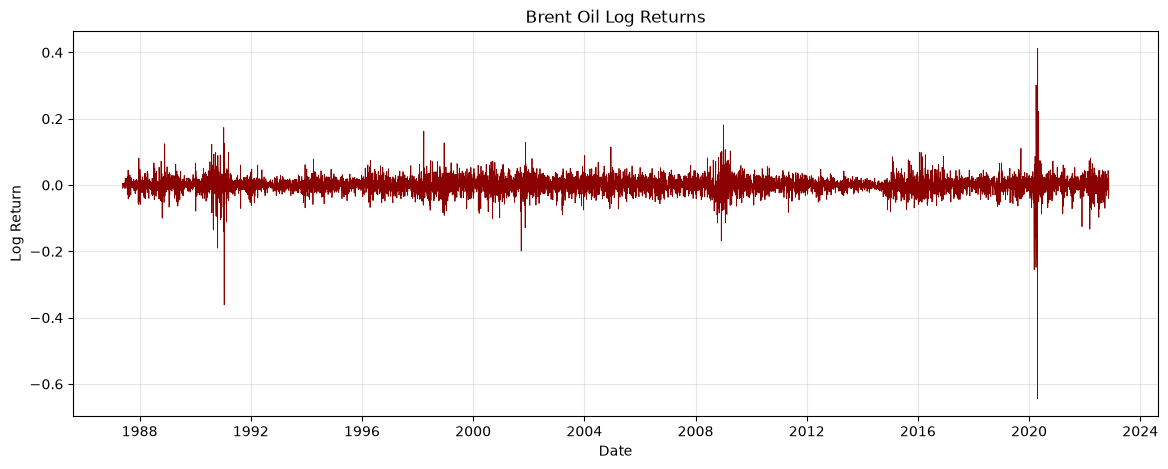

In [9]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['LogReturn'], linewidth=0.6, color='darkred')
plt.title('Brent Oil Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(alpha=0.3)
plt.savefig("../reports/figures/brent_log_returns.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller

result_price = adfuller(df['Price'].dropna())
result_return = adfuller(df['LogReturn'].dropna())

print(f"Price ADF p-value: {result_price[1]:.4f}")
print(f"Log Return ADF p-value: {result_return[1]:.4f}")

Price ADF p-value: 0.2893
Log Return ADF p-value: 0.0000
